# Hierarchical clustering demo for charity CRM segmentation

This notebook builds a **simple customer segmentation example** using **artificial charity CRM data** and **hierarchical clustering**.

The aim is to keep the demo practical and easy to follow:

- We generate a small customer dataset with a few **already standardised numeric features**
- We apply **hierarchical clustering** with `linkage` from `scipy.cluster.hierarchy`
- We visualise the hierarchy using a **dendrogram**
- We profile the resulting clusters and relate them back to familiar CRM patterns

In a real charity CRM setting, clustering can help identify groups such as:

- donors with **low annual value but high lifetime value**
- donors with **high current value but low lifetime value**
- supporters who appear **lapsed or disengaged**


## Import the libraries

We use:

- **NumPy** to generate artificial data
- **pandas** to work with the dataset in tabular form
- **matplotlib** for plotting
- **SciPy** for hierarchical clustering and the dendrogram


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

np.random.seed(42)

## Generate an artificial charity CRM dataset

We will create three deliberately planted CRM-style patterns.

Each row represents one supporter/customer, and each feature is already on a standardised scale
(so values near `0` are average, positive values are above average, and negative values are below average).

### Features

- `annual_value_z`: giving in the last 12 months
- `lifetime_value_z`: long-term value across the relationship
- `recency_z`: how recently the supporter donated or engaged
- `engagement_z`: a general engagement score (campaign responses, events, email clicks, etc.)

### Planted patterns

1. **Loyal long-term supporters**  
   Lower recent annual value, but high lifetime value and good engagement

2. **High-current-value newer supporters**  
   High annual value and recent activity, but lower lifetime value because the relationship is newer

3. **Lapsed low-value contacts**  
   Low annual value, low lifetime value, low recency, and low engagement

These hidden patterns are just for teaching. In a real unsupervised problem, we would not know them in advance.


In [2]:
n_per_group = 20

# Cluster centres are already expressed on a roughly standardised scale.
centres = {
    "Loyal long-term supporters": [-1.0,  1.4,  0.5,  0.8],
    "High-current-value newer supporters": [ 1.5, -0.7,  1.1,  0.4],
    "Lapsed low-value contacts": [-0.8, -1.0, -1.3, -1.1],
}

feature_names = ["annual_value_z", "lifetime_value_z", "recency_z", "engagement_z"]

rows = []
for segment_name, centre in centres.items():
    values = np.random.normal(loc=centre, scale=[0.35, 0.35, 0.30, 0.30], size=(n_per_group, 4))
    for row in values:
        rows.append([segment_name, *row])

df = pd.DataFrame(rows, columns=["planted_segment", *feature_names])

# Give each record a simple customer ID for display purposes.
df.insert(0, "customer_id", [f"C{i:03d}" for i in range(1, len(df) + 1)])

df.head()

,customer_id,planted_segment,annual_value_z,lifetime_value_z,recency_z,engagement_z
0,C001,Loyal long-term supporters,-0.826150,1.351607,0.694307,1.256909
1,C002,Loyal long-term supporters,-1.081954,1.318052,0.973764,1.030230
2,C003,Loyal long-term supporters,-1.164316,1.589896,0.360975,0.660281
3,C004,Loyal long-term supporters,-0.915313,0.730352,-0.017475,0.631314
4,C005,Loyal long-term supporters,-1.354491,1.509987,0.227593,0.376309


A quick note on interpretation:

Because the variables are already standardised, a value such as `1.2` means **above average** for that feature,
while `-1.2` means **below average**.

That makes the cluster profiles easier to explain later.


In [5]:
df[feature_names].describe().round(2)

,annual_value_z,lifetime_value_z,recency_z,engagement_z
count,60.00,60.00,60.00,60.00
mean,-0.13,-0.08,0.08,0.06
std,1.18,1.07,1.03,0.84
min,-1.52,-1.65,-1.62,-1.58
25%,-1.06,-0.86,-1.10,-0.84
50%,-0.76,-0.57,0.47,0.35
75%,1.26,1.15,0.81,0.67
max,2.15,1.95,1.67,1.36


## Run hierarchical clustering

We now cluster the supporters using **Ward linkage**.

Ward linkage works well for this kind of numeric data because it tries to merge observations in a way that keeps
within-cluster variation as small as possible.

The `linkage` function returns a matrix that stores the sequence of merges used to build the hierarchy.


In [6]:
X = df[feature_names].values

Z = linkage(X, method="ward")
Z[:5]  # show the first few merges

array([[27.        , 32.        ,  0.19649732,  2.        ],
       [ 0.        , 17.        ,  0.20273799,  2.        ],
       [24.        , 37.        ,  0.20544643,  2.        ],
       [20.        , 26.        ,  0.24268116,  2.        ],
       [ 3.        ,  9.        ,  0.25774229,  2.        ]])

## Visualise the hierarchy with a dendrogram

The dendrogram shows how observations are progressively merged into larger and larger groups.

Things to explain when presenting:

- observations that merge at a **low height** are more similar
- large **vertical jumps** suggest more distinct group boundaries
- cutting the tree at a chosen height gives a set of clusters

For a small teaching dataset like this, a full dendrogram is readable. On larger CRM datasets, you would often
use truncation or sample the data.


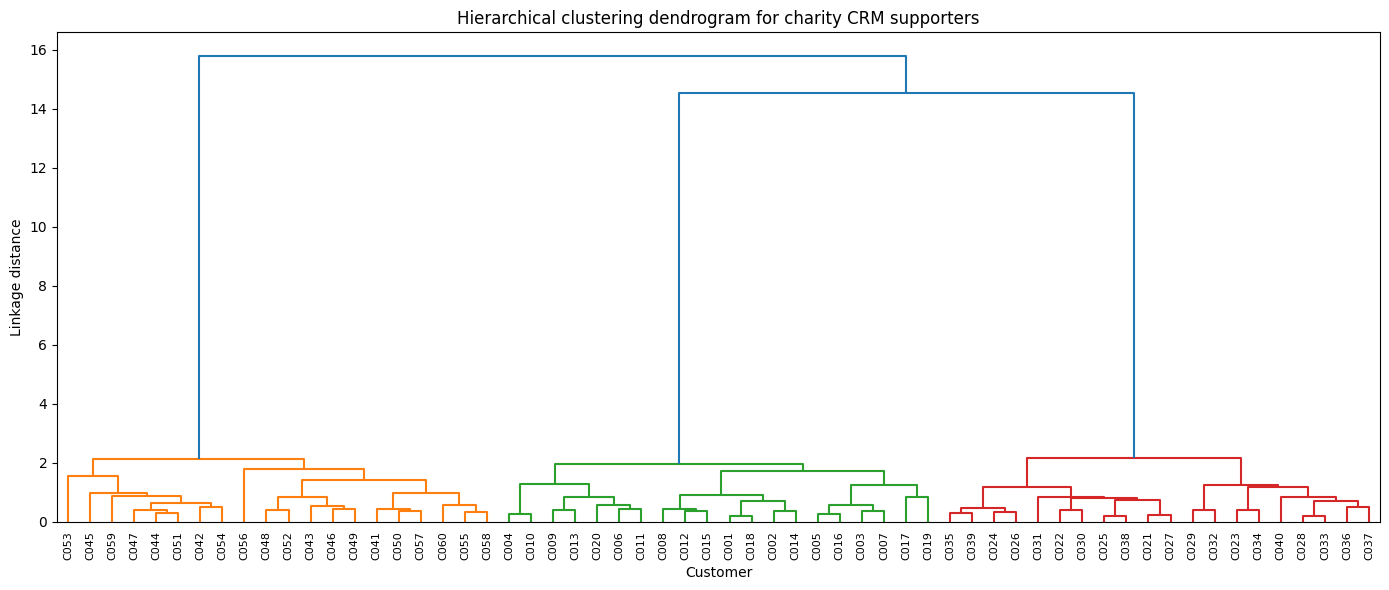

In [9]:
plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    labels=df["customer_id"].to_list(),
    leaf_rotation=90,
    leaf_font_size=8,
)
plt.title("Hierarchical clustering dendrogram for charity CRM supporters")
plt.xlabel("Customer")
plt.ylabel("Linkage distance")
plt.tight_layout()
plt.show()

## Choose a cluster cut

For teaching purposes, we will cut the dendrogram into **3 clusters**, because we know the artificial data was generated
from three broad CRM-style patterns.

In a real project, deciding the number of clusters would involve more judgement:
business usefulness, cluster stability, dendrogram shape, and sometimes additional diagnostics.


In [11]:
df["cluster"] = fcluster(Z, t=3, criterion="maxclust")

In [ ]:
df.sample(10)

,customer_id,planted_segment,annual_value_z,lifetime_value_z,recency_z,engagement_z,cluster
34,C035,High-current-value newer supporters,1.225861,-0.812722,1.344055,0.030741,3
10,C011,Loyal long-term supporters,-0.741537,1.459979,0.465306,0.709669,2
55,C056,Lapsed low-value contacts,0.010130,-1.653543,-1.094122,-1.583815,1
51,C052,Lapsed low-value contacts,-1.282184,-1.328239,-1.145489,-0.945864,1
12,C013,Loyal long-term supporters,-0.879734,0.782936,0.597225,0.684475,2
7,C008,Loyal long-term supporters,-1.210224,1.297907,0.319488,1.355683,2
1,C002,Loyal long-term supporters,-1.081954,1.318052,0.973764,1.030230,2
17,C018,Loyal long-term supporters,-0.873427,1.174208,0.608419,1.261411,2
26,C027,High-current-value newer supporters,1.443550,-0.558582,1.665856,0.452373,3
5,C006,Loyal long-term supporters,-0.487023,1.320978,0.520258,0.372576,2


## Profile the resulting clusters

A cluster label such as `1`, `2`, or `3` is just an ID.  
The useful part is the **average feature pattern** inside each cluster.


In [13]:
cluster_profile = (
    df.groupby("cluster")[feature_names]
      .mean()
      .round(2)
      .sort_index()
)

cluster_sizes = df["cluster"].value_counts().sort_index()

print("Cluster sizes:")
display(cluster_sizes.to_frame(name="count"))

print("\nAverage standardised feature values by cluster:")
display(cluster_profile)

Cluster sizes:


,count
cluster,
1,20
2,20
3,20



Average standardised feature values by cluster:


,annual_value_z,lifetime_value_z,recency_z,engagement_z
cluster,,,,
1,-0.85,-0.95,-1.25,-1.00
2,-1.03,1.31,0.42,0.83
3,1.47,-0.60,1.07,0.36


Because this is simulated data, we can also compare the discovered clusters with the hidden planted segments.

This is **not** something we would normally have in a real unsupervised exercise, but it is helpful for teaching because it shows
whether the clustering has recovered the patterns we built into the data.


In [14]:
comparison = pd.crosstab(df["cluster"], df["planted_segment"])
comparison

planted_segment,High-current-value newer supporters,Lapsed low-value contacts,Loyal long-term supporters
cluster,,,
1,0,20,0
2,0,0,20
3,20,0,0


## Interpreting the patterns

You should find that the clustering separates the supporters into broadly meaningful CRM segments.

Typical interpretation:

- One cluster should show **low `annual_value_z` but high `lifetime_value_z`**.  
  These are likely **loyal long-term supporters** who have built up substantial value over time, even if their recent giving is modest.

- Another cluster should show **high `annual_value_z` but lower `lifetime_value_z`**.  
  These look like **high-current-value newer supporters**: very active now, but without a long historical value yet.

- A third cluster should show **low recency and low engagement**, often alongside low annual and lifetime value.  
  This group resembles **lapsed or disengaged contacts**.

### Why this is useful in CRM

Once a charity sees patterns like these, it can tailor strategy:

- **Loyal long-term supporters** might be suitable for stewardship, regular giving retention, or legacy messaging
- **High-current-value newer supporters** might benefit from onboarding and cultivation to increase lifetime value
- **Lapsed low-value contacts** might need reactivation campaigns, lower-cost channels, or may be deprioritised

### Important teaching point

The cluster numbers themselves are not meaningful.  
What matters is the **profile** of each cluster and whether it gives a useful business story.


## Extension challenge

To extend this demo, you could:

- add more CRM variables such as frequency, channel preference, event attendance, or response rate
- compare hierarchical clustering with **k-means**
- standardise the variables inside the notebook rather than generating them already standardised
- plot a 2D scatter chart of two features coloured by cluster
- discuss how poor feature choice can create misleading segments